## Experiment 2: Fusion Benchmark

Compare eager PyTorch with `torch.compile` for a chain of pointwise operations that squares the input, adds 1, applies ReLU, and multiplies by 0.5. Measure the latency and inspect the execution to determine whether compilation fuses the operations into fewer GPU kernels, reducing kernel-launch overhead and intermediate global-memory traffic.


In [40]:
# checking gpu info
!nvidia-smi

Sat Sep  5 00:34:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             30W /   70W |   13199MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
# import libraries
import torch # standard torch import
# from torch.utils.cpp_extension import load_inline # for loading inline C++ code
import matplotlib.pyplot as plt # for plotting
import torch._inductor.config as config # for tracing

config.trace.enabled = True

# versioning libraries
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")

# check if GPU is available
print(f"GPU available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA version: 12.8
cuDNN version: 91900
GPU available: True


In [42]:
N=[2**i for i in [10,12,15,20,26,30]]

In [43]:
N

[1024, 4096, 32768, 1048576, 67108864, 1073741824]

In [44]:
# eager implementation
def kernel_fn(x):
    x= x*x
    x= x+1
    x= torch.relu(x)
    x= x*0.5
    return x

# compile implementation
compiled_kernel = torch.compile(kernel_fn)


In [45]:
# implementing warmup for both kernels at the same time
def benchmark(n, kernel_fn, compiled_kernel):
    # allocate memory
    x = torch.randn(n, device='cuda')
    # warmup
    for _ in range(10):
        kernel_fn(x)
        compiled_kernel(x)

    # synchronize
    torch.cuda.synchronize()

    # CUDA Events for timing
    start_eager = torch.cuda.Event(enable_timing=True)
    end_eager = torch.cuda.Event(enable_timing=True)
    start_compiled = torch.cuda.Event(enable_timing=True)
    end_compiled = torch.cuda.Event(enable_timing=True)

    # timing
    start_eager.record()
    kernel_fn(x)
    end_eager.record()
    torch.cuda.synchronize()
    eager_time = start_eager.elapsed_time(end_eager)

    # timing
    start_compiled.record()
    compiled_kernel(x)
    end_compiled.record()
    torch.cuda.synchronize()
    compiled_time = start_compiled.elapsed_time(end_compiled)

    return eager_time, compiled_time




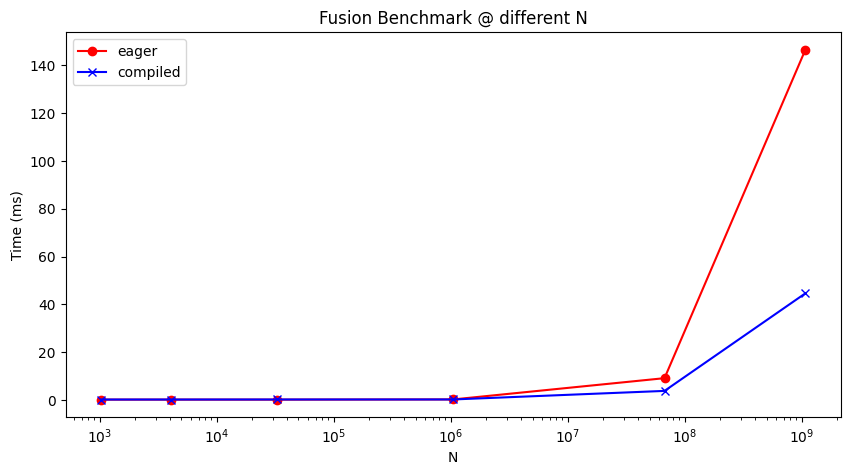

In [46]:
# loop through N
eager_times = []
compiled_times = []
for n in N:
    eager_time, compiled_time = benchmark(n, kernel_fn, compiled_kernel)
    eager_times.append(eager_time)
    compiled_times.append(compiled_time)

# plot
plt.figure(figsize=(10,5))
plt.plot(N, eager_times, label='eager', marker='o', color='red')
plt.plot(N, compiled_times, label='compiled', marker='x', color='blue')
plt.xscale('log')
plt.xlabel('N')
plt.ylabel('Time (ms)')
plt.title('Fusion Benchmark @ different N')
plt.legend()
plt.show()




The output file is stored in a tmp folder of torch inductor search from the linux root folder and use your privileges to get to there...

I've attached the file of the compiled kernel!